In [57]:
import numpy as np
import cmath
import math
import sympy as sp
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import statistics as stat
import scipy.stats as spstat
import statsmodels.distributions.empirical_distribution as empir
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.factorplots import interaction_plot
import statsmodels.api as sma
import matplotlib.lines as mlines

### **1.1 Oefening 1**
Bereken $\frac{\pi}{4}+\frac{\pi}{3}-\frac{\pi}{11}$ in kommagetal (6 cijfers na de komma).
* **Oplossing:** 1.546996

In [6]:
res = math.pi/4 + math.pi/3 - math.pi/11
print(f"oplossing: {res:.4f}")

oplossing: 1.5470


### **1.2 Oefening 2**
Bereken op een efficiënte manier: $1^{2}+2^{2}+\cdot\cdot\cdot+100^{2}$
* **Oplossing:** 338350

In [7]:
res = 0
for i in range (1,101):
    res += i**2
print(res)

338350


### **1.3 Oefening 3**
Bereken som, product en quotiënt van de complexe getallen $z_{1}=3+2j$ en $z_{2}=1-j.$
* **Oplossing:** som: $4+j,$ product: $5-j$ quotiënt: $\frac{1}{2}+\frac{5}{2}j$

In [8]:
z1 = 3 + 2j
z2 = 1-1j
som = z1+z2
product = z1*z2
quotient=z1/z2
print(f"som = {som}, product = {product}, quotiënt = {quotient}")

som = (4+1j), product = (5-1j), quotiënt = (0.5+2.5j)


### **1.4 Oefening 4**
Stel $z=\sqrt{2}e^{3\pi~j/5}$. Bepaal het reëel en imaginair deel. Bepaal (in graden) het argument (=poolhoek) van het complex toegevoegde van $(z+1)$.
* **Oplossing:** 
  * Reëel deel: -0.437016024448821, 
  * imaginair deel: 1.3449970239279148
  * De poolhoek: 67.28696631637692

In [12]:
z= math.sqrt(2)*cmath.exp(3j*math.pi/5)
z1 = (z+1).conjugate()
print(f"reëel deel: {z.real}, imaginair deel: {z.imag}, poolhoek: {math.degrees(cmath.phase(z1))}")

reëel deel: -0.437016024448821, imaginair deel: 1.3449970239279148, poolhoek: -67.28696631637692


### **1.5 Oefening 5**
Voer op de meest handige manier de matrix A in die 18 rijen bevat.
$$A=\begin{pmatrix}1&3&5&7&...&45&47\\ 1&3&5&7&..&45&47\\ 1&3&5&7&...&45&47\\ 1&3&5&7&...&45&47\\ 1&3&5&7&...&45&47\end{pmatrix}.$$

In [13]:
v = np.arange(1,48,2)
A = np.tile(v,(18,1))

print(A)

[[ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 29 31 33 35 37 39 41 43 45 47]
 [ 1  3  5  7  9 11 13 15

### **1.6 Oefening 6**
Voer op de meest handige manier de matrix B in.
$$B=\begin{pmatrix}1&2&3&4&...&9\\ 1&4&9&16&...&9^{2}\\ 1&8&27&...&...&9^{4}\\ 1&32&...&...&9^{5}\end{pmatrix}$$

In [16]:
v = np.arange(1,10)
machten = np.array([[1],[2],[3],[5]])
print(v**machten)

[[    1     2     3     4     5     6     7     8     9]
 [    1     4     9    16    25    36    49    64    81]
 [    1     8    27    64   125   216   343   512   729]
 [    1    32   243  1024  3125  7776 16807 32768 59049]]


### **1.7 Oefening 7**
Maak een schatting van $\pi$ via een Monte Carlo simulatie, d.w.z. $\frac{\pi}{4}$ waarbij 4 de oppervlakte is van het vierkant $[-1,1]\times[-1,1]$ en p de kans voorstelt dat een willekeurig punt in dit vierkant gelegen is binnen de cirkel met straal 1 en middelpunt (0,0). p is het quotiënt van de oppervlaktes van cirkel en rechthoek en is gelijk aan $\frac{\pi}{4}$
* **Oplossing:** Genereer bijvoorbeeld 1000 willekeurige punten binnen het vierkant. Gebruik een for-lus waarin je telt hoeveel punten binnen de cirkel gelegen zijn. Dan kan $\pi$ geschat worden als dit aantal/1000 maal 4.

In [17]:
aantal_punten = 1000

x=np.random.uniform(-1,1,aantal_punten)
y=np.random.uniform(-1,1,aantal_punten)

punten_binnen_cirkel =np.sum((x**2+y**2) <=1)

pi_schatting = (punten_binnen_cirkel / aantal_punten) *4
print(pi_schatting)

3.204


### **1.8 Oefening 8**
Bereken de oppervlakte van de driehoek met hoekpunten $a(1,2,0),$ $b(3,0,-3)$ en $c(5,2,6)$.
* **Oplossing:** 14

In [19]:
a = np.array([1,2,0])
b= np.array([3,0,-3])
c = np.array([5,2,6])

ab = b-a
ac = c-a

print(1/2*np.linalg.norm(np.cross(ab,ac)))

14.0


### **1.9 Oefening 9**
Bereken het gemiddelde van de elementen uit de verzameling $\{f(0),f(0.1),...,f(1)\}$ met $f(t)=\frac{t}{1+\sqrt{t}}.$ (Werk zonder lussen!)
* **Oplossing:** 0.277209136544736

In [20]:
t = np.linspace(0,1,11)
print(np.mean(t/(1+np.sqrt(t))))


0.277209136544736


### **1.10 Oefening 10**
Een rechthoekige driehoek heeft een omtrek van 5 cm en de lengte van de schuine zijde is $2/3$ van de som van de lengtes van de rechthoekszijden. Wat is de waarde van de zijden van deze driehoek?
* **Oplossing:** geen reële oplossing

In [22]:
a, b ,c = sp.symbols('a b c', real=True, positive=True)

vgl1 = sp.Eq(a+b+c,5)
vgl2=sp.Eq(c,2/3*(a+b))
vgl3=sp.Eq(c**2,a**2+b**2)

opl = sp.solve((vgl1,vgl2,vgl3), (a,b,c))
if not opl:
    print("Er zijn geen reële oplossingen voor deze driehoek.")
else:
    for sol in opl:
        print(f"Oplossing gevonden: a={sol[0]}, b={sol[1]}, c={sol[2]}")

Er zijn geen reële oplossingen voor deze driehoek.


### **1.11 Oefening 11**
Hoeveel van de volgende getallen zijn groter dan 0.5? sin(1), sin(2), sin(3),..., sin (1000)
* **Oplossing:** 332

In [23]:
aantal = 0
for i in range(1,1001):
    if(math.sin(i)>0.5):
        aantal +=1
print(aantal)

332


### **1.12 Oefening 12**
Bouw de faculteitfunctie na met een for-lus (controleer voor 10!) $10!=362880$

In [25]:
faculteit = 1
for i in range(1,11):
    faculteit *=i
print(faculteit)

3628800


### **1.13 Oefening 13**
Bereken $\Sigma_{n=0}^{10}n$! met een beknopt commando op één regel.
* **Oplossing:** 4037914

In [26]:
print(sum(math.factorial(n) for n in range(11)))

4037914


### **1.14 Oefening 14**
Bereken $\tan(2~Bg~\cos(-\frac{1}{5}))$
* **Oplossing:** 0.425998216136205

In [27]:
print(math.tan(2*math.acos(-1/5)))

0.425998216136205


### **1.15 Oefening 15**
Een rechthoekige driehoek heeft een omtrek van 5 cm. Wat is de waarde van de zijden wanneer de driehoek maximale oppervlakte heeft.
* **Oplossing:** $b=1.4645$, oppervlakte $=1.0723$

In [ ]:
a, b, c = sp.symbols('a b c', real=True, positive=True)

vgl1 = sp.Eq(c,5-a-b)
vgl2 = sp.Eq(c**2,a**2+b**2)

opl = sp.solve((vgl1,vgl2), (b,c))

b_formule = opl[0][0]
c_formule = opl[0][1]

opp_formule = 0.5 * a * b_formule
opp_func = sp.lambdify(a, -opp_formule, 'numpy')
resultaat = minimize(opp_func, x0=1.0, bounds=[(0.1, 2.4)])

a_opt = resultaat.x[0]
b_opt = float(b_formule.subs(a, a_opt))
c_opt = float(c_formule.subs(a, a_opt))
max_opp = -resultaat.fun

print(f"Zijde b: {b_opt:.4f} cm")
print(f"Maximale oppervlakte: {max_opp:.4f} cm²")

### **1.16 Oefening 16**
Bepaal de snijpunten met de X-as van $\frac{x^{3}-5x^{2}+2x+8}{1+Bgtg(\frac{x}{2})}.$
* **Oplossing:** -1, 2, 4

In [ ]:
x = sp.symbols('x')

teller = x**3-5*x**2+2*x+8
noemer = 1 + sp.atan(x/2) # type: ignore

nulpunten = sp.solve(teller, x)

geldige_snijpunten = [punt for punt in nulpunten if noemer.subs(x,punt).evalf() != 0]
print(geldige_snijpunten)


[-1, 2, 4]


### **1.17 Oefening 17**
Los op over IR: $2x^{3}-x^{2}-15x+18>0$
* **Oplossing:** $x\in]-3,\frac{3}{2}[\cup]2,\infty[$

In [29]:
x = sp.symbols('x')
veelterm = 2*x**3 - x**2 - 15*x + 18

oplossing = sp.solve(veelterm > 0, x, domain=sp.S.Reals)

print(f"De ongelijkheid: {veelterm} > 0")
print(f"Oplossingsverzameling in intervalnotatie: {oplossing}")

De ongelijkheid: 2*x**3 - x**2 - 15*x + 18 > 0
Oplossingsverzameling in intervalnotatie: ((-3 < x) & (x < 3/2)) | ((2 < x) & (x < oo))


### **1.18 Oefening 18**
Los op over IR: $x^{5}-5x=-2$.
* **Oplossing:** $x=0.402$ of $x=1.37$ of $x=-1.5820$

In [31]:
x = sp.symbols('x')
f = x**5 - 5*x + 2

roots = sp.solve(sp.Eq(f, 0), x)

reele_nulpunten = [float(r.evalf()) for r in roots if r.is_real]
reele_nulpunten.sort()

print("De reële nulpunten zijn:")
for nulpunt in reele_nulpunten:
    print(f"x = {nulpunt:.4f}")

De reële nulpunten zijn:
x = -1.5820
x = 0.4021
x = 1.3719


### **1.19 Oefening 19**
Bepaal de asymptoten van de kromme met vergelijking $y=\frac{x^{4}+3x^{3}}{8x^{3}+1}$
Maak daarbij gebruik van het commando 'limit' voor symbolische functies.
* **Oplossing:** y $=\frac{1}{8}x+\frac{3}{8}$ is een SA voor $x\rightarrow+\infty,$ $y=\frac{1}{8}x+\frac{3}{8}$ is een SA voor $x\rightarrow-\infty$. Er is een VA bij $x=-\frac{1}{2}.$

In [33]:
x=sp.symbols('x', real=True)
f=(x**4+3*x**3)/(8*x**3+1)

noemer = 8*x**3+1
nulp_noemer = sp.solve(noemer,x)

for nulpunt in nulp_noemer:
    lim_links = sp.limit(f,x,nulpunt,dir='-')
    lim_rechts = sp.limit(f,x,nulpunt,dir='+')

    if abs(lim_links) == sp.oo or abs(lim_rechts) == sp.oo:
        print(f"er is een VA op x = {nulpunt}")

voor_limieten = [(sp.oo, "+oneindig"),(-sp.oo,"-oneindig")]

for limiet_waarde, label in voor_limieten:
    a = sp.limit(f/x,x,limiet_waarde)
    b=sp.limit(f-a*x,x,limiet_waarde)

    if a.is_finite and a !=0 and b.is_finite:
        print(f"voor x -> {label} is de SA: y = {a}*x + {b}")

er is een VA op x = -1/2
voor x -> +oneindig is de SA: y = 1/8*x + 3/8
voor x -> -oneindig is de SA: y = 1/8*x + 3/8


### **1.20 Oefening 20**
Schets de kromme $y=Bgtg(\frac{x-1}{2}-\frac{1}{2x-2})$
Bepaal de limiet in 1 en $in+\infty$.
Bepaal $y^{\prime}$. Zoek punten waarin $y^{\prime}=2$. Verklaar de resultaten op de grafiek
* **Oplossing:** 
  * De linker- en rechterlimiet in $x=1$ streven respectievelijk naar $\frac{\pi}{2}$ en $-\frac{\pi}{2}.$
  * Als x naar + $\infty$ nadert, nadert f(x) naar $\frac{\pi}{2}.$
  * Als x naar - $\infty$ nadert, nadert f(x) naar $-\frac{\pi}{2}.$ 
  * Geen punten waarin $y^{\prime}=2$

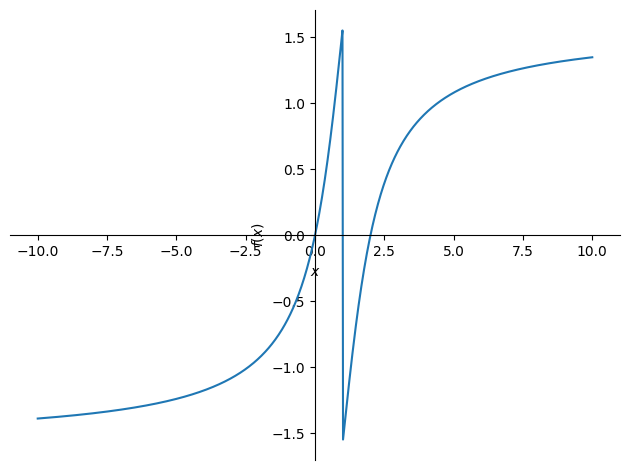

In [ ]:
x = sp.symbols('x')
f = sp.atan((x-1)/2-1/(2*x-2))
sp.plotting.plot(f,(x,-10,10))

In [36]:
lim_links = sp.limit(f, x, 1, dir='-')
lim_rechts = sp.limit(f, x, 1, dir='+')

lim_plus_inf = sp.limit(f, x, sp.oo)
lim_min_inf = sp.limit(f, x, -sp.oo)

print(f"Limiet voor x -> +oo: {lim_plus_inf}")
print(f"Limiet voor x -> -oo: {lim_min_inf}")

y_prime = sp.diff(f, x).simplify()
print(f"De afgeleide y' is: {y_prime}")

mogelijke_punten = sp.solve(sp.Eq(y_prime, 2), x)

geldige_punten = []
for punt in mogelijke_punten:
    if (punt - 1) != 0:
        geldige_punten.append(punt)

if not geldige_punten:
    print("Geen geldige punten waarin y' = 2.")
    print(f"(Het enige theoretische punt was x = {mogelijke_punten[0]}, maar dat valt buiten het domein van de functie).")
else:
    print(f"Punten waar y' = 2: {geldige_punten}")

Limiet voor x -> +oo: pi/2
Limiet voor x -> -oo: -pi/2
De afgeleide y' is: 2/(x**2 - 2*x + 2)
Geen geldige punten waarin y' = 2.
(Het enige theoretische punt was x = 1, maar dat valt buiten het domein van de functie).


### **1.21 Oefening 21**
a) Definieer de functie $f(x)=\frac{x^{2}}{3}-4$

b) Bepaal de snijpunten van de kromme $y=f(x)$ met $y=2$

c) Bepaal het punt (x, y) waarin de raaklijn evenwijdig is met de eerste bissectrice

d) Bepaal de oppervlakte van het vlak gebied ingesloten door de X-as, $x=4$ $x=8$ en $y=f(x)$
* **Oplossing:**
  * b) $(-3\sqrt{2},2)$ & $(3\sqrt{2},2)$
  * c) (1.5, -3.25)
  * d) 33.8

In [ ]:
# a
x=sp.symbols('x')
f=x**2/3-4

# b
snijp_x = sp.solve(sp.Eq(f,2),x)
snijp = [(val,2) for val in snijp_x]
print(f"De snijpunten zijn: {snijp}")

#c
f_prime = sp.diff(f,x)
x_raakpunt = sp.solve(sp.Eq(f_prime,1),x)[0]
y_raakpunt=f.subs(x,x_raakpunt)
print(f"Het punt is: ({x_raakpunt.evalf()}, {y_raakpunt.evalf()})")

# d
opp = sp.integrate(f,(x,4,8))
print(f"De exacte oppervlakte is: {opp}")
print(f"Numerieke waarde: {opp.evalf():.1f}"

De snijpunten zijn: [(-3*sqrt(2), 2), (3*sqrt(2), 2)]
Het punt is: (1.50000000000000, -3.25000000000000)
De exacte oppervlakte is: 304/9
Numerieke waarde: 33.8


### **1.22 Oefening 22**
Bereken de oppervlakte van het gebied begrensd door $y=6~x-x^{2}$ en $y=x^{2}-2x$. Maak een tekening.
* **Oplossing:** $64/3$

In [38]:
x = sp.Symbol('x', real=True)

f = 6*x - x**2
g = x**2 - 2*x

snijpunten = sp.solve(sp.Eq(f, g), x)
snijpunten.sort()
x_links = snijpunten[0]
x_rechts = snijpunten[1]

print(f"De curven snijden elkaar in x = {x_links} en x = {x_rechts}")

oppervlakte = sp.integrate(f - g, (x, x_links, x_rechts))

print(f"De exacte oppervlakte is: {oppervlakte}")

De curven snijden elkaar in x = 0 en x = 4
De exacte oppervlakte is: 64/3


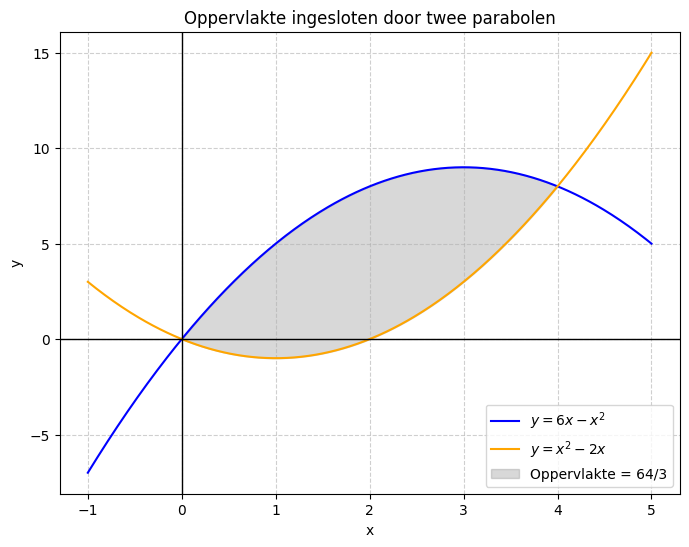

In [39]:
f_numeriek = sp.lambdify(x, f, 'numpy')
g_numeriek = sp.lambdify(x, g, 'numpy')

x_waarden = np.linspace(float(x_links) - 1, float(x_rechts) + 1, 400)

y_f = f_numeriek(x_waarden)
y_g = g_numeriek(x_waarden)

plt.figure(figsize=(8, 6))
plt.plot(x_waarden, y_f, label='$y = 6x - x^2$', color='blue')
plt.plot(x_waarden, y_g, label='$y = x^2 - 2x$', color='orange')

x_arceer = np.linspace(float(x_links), float(x_rechts), 100)
plt.fill_between(x_arceer, f_numeriek(x_arceer), g_numeriek(x_arceer), 
                 color='grey', alpha=0.3, label='Oppervlakte = 64/3')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.title('Oppervlakte ingesloten door twee parabolen')
plt.xlabel('x')
plt.ylabel('y')

# Toon de plot
plt.show()

### **1.23 Oefening 23**
Schets de krommen $y=\frac{1}{1+x^{2}}$ en $y=\frac{x^{2}}{2}$. Gebruik verschillende kleuren voor de krommen.
Bepaal de snijpunten en bereken de oppervlakte van het gebied ingesloten door beide krommen. Geef daarvoor een analytische en een numerieke waarde. Gebruik daarnaast ook een numerieke integratiemethode en vergelijk de resultaten.
* **Oplossing:** $\pi/2-1/3$. De numerieke waarde 1.237462993462 wordt quasi ook bekomen met de numerieke methode.

[-1, 1, -sqrt(2)*I, sqrt(2)*I]
x1 =  -1
x2 =  1
y1 =  1/2
y2 =  1/2


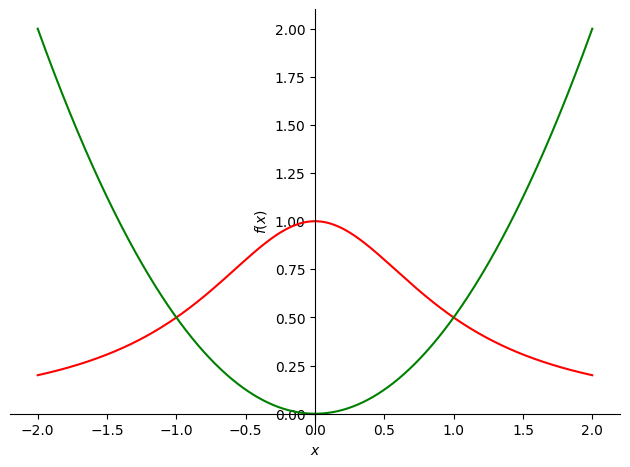

In [40]:
from sympy.plotting import plot
x = sp.symbols("x")
f1 = 1/(1+x**2)
f2 = (x**2)/2
vgl = sp.Eq(f1-f2,0)
xsnijpunt = sp.solve(vgl,x)
print(xsnijpunt)

x1=xsnijpunt[0]
print("x1 = ",x1)
x2=xsnijpunt[1]
print("x2 = ",x2)
y1=f1.subs(x,x1)
print("y1 = ",y1)
y2=f1.subs(x,x2)
print("y2 = ",y2)

plotf=plot(f1,(x,-2,2), show=False,line_color="r")
plotg=plot(f2,(x,-2,2), show=False,line_color="g")
plotf.extend(plotg)
plotf.show()

### **1.24 Oefening 24**
Bereken het volume van het deel van het cilinderoppervlak $x^{2}+y^{2}=2x$ tussen $z=0$ en $z=4$.
Vergelijk CaCo met CiCo voor dit probleem.
* **Oplossing:** 4 $\pi$

In [41]:
x, y, z = sp.symbols('x y z', real=True)
r, theta = sp.symbols('r theta', real=True)

int_z = sp.integrate(1, (z, 0, 4))
int_y = sp.integrate(int_z, (y, -sp.sqrt(2*x - x**2), sp.sqrt(2*x - x**2)))
vol_caco = sp.integrate(int_y, (x, 0, 2))

print(f"Volume (CaCo) = {vol_caco}")

int_z_cico = sp.integrate(r, (z, 0, 4))
int_r_cico = sp.integrate(int_z_cico, (r, 0, 2*sp.cos(theta)))
vol_cico = sp.integrate(int_r_cico, (theta, -sp.pi/2, sp.pi/2))

print(f"Volume (CiCo) = {vol_cico}")

Volume (CaCo) = 4*pi
Volume (CiCo) = 4*pi


### **1.25 Oefening 25**
Schets de kromme met parametervoorstelling 

$\begin{cases}x=\frac{1}{t-1}\\ y=1+t^{2}\end{cases}$ 
(gebruik een rode stippellijn voor de asymptoten). 

Bepaal het/de punt(en) met horizontale raaklijn.
* **Oplossing:** (-1, 1)

In [43]:
t = sp.Symbol('t', real=True)

x_t = 1 / (t - 1)
y_t = 1 + t**2

dy_dt = sp.diff(y_t, t)
dx_dt = sp.diff(x_t, t)

t_horizontaal = sp.solve(sp.Eq(dy_dt, 0), t)

for t_val in t_horizontaal:
    if dx_dt.subs(t, t_val) != 0:
        x_val = x_t.subs(t, t_val)
        y_val = y_t.subs(t, t_val)
        print(f"Horizontale raaklijn in punt: ({x_val}, {y_val}) bij parameter t = {t_val}")

Horizontale raaklijn in punt: (-1, 1) bij parameter t = 0


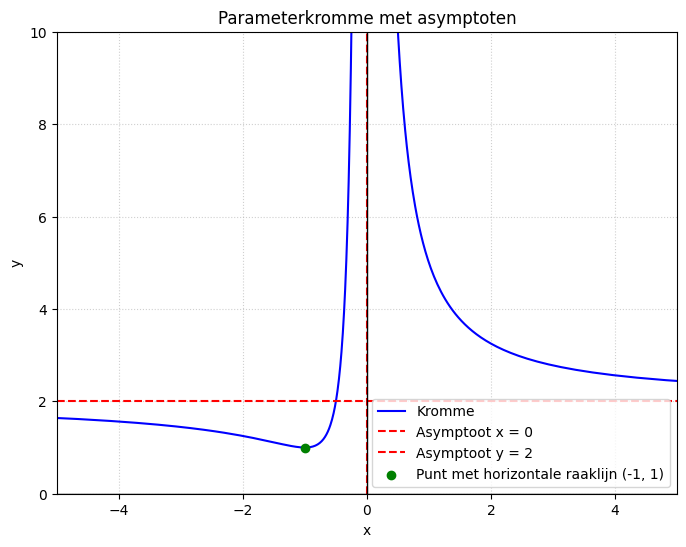

In [45]:
t_waarden_links = np.linspace(-10, 0.95, 400)
t_waarden_rechts = np.linspace(1.05, 10, 400)

x_num = sp.lambdify(t, x_t, 'numpy')
y_num = sp.lambdify(t, y_t, 'numpy')

plt.figure(figsize=(8, 6))

plt.plot(x_num(t_waarden_links), y_num(t_waarden_links), color='blue', label='Kromme')
plt.plot(x_num(t_waarden_rechts), y_num(t_waarden_rechts), color='blue') 

plt.axvline(0, color='red', linestyle='--', label='Asymptoot x = 0')
plt.axhline(2, color='red', linestyle='--', label='Asymptoot y = 2')

plt.scatter([-1], [1], color='green', zorder=5, label='Punt met horizontale raaklijn (-1, 1)')

plt.xlim(-5, 5)
plt.ylim(0, 10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.legend()
plt.title('Parameterkromme met asymptoten')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

### **1.26 Oefening 26**
Maak een 3D plot en een contourplot van $z=\frac{sin\sqrt{x^{2}+y^{2}}}{\sqrt{x^{2}+y^{2}}},-10\le x\le10,-10\le y\le10.$ 

met de asymptoten $x=0$ en $y=2$.

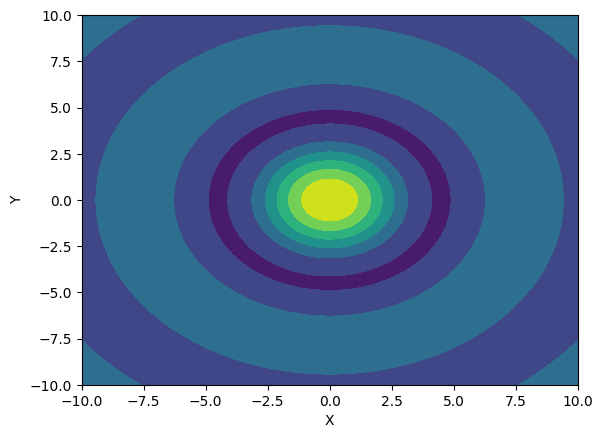

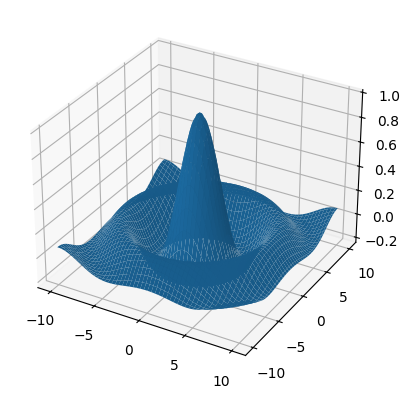

In [ ]:
xwaarden = np.linspace(-10,10,100)
ywaarden = np.linspace(-10,10,100)
[X,Y] = np.meshgrid(xwaarden,ywaarden)
Z = np.sin(np.sqrt(X**2+Y**2))/np.sqrt(X**2+Y**2)

fig1,ax1=plt.subplots()
ax1.contourf(X,Y,Z)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")

fig2 = plt.figure()
ax2 = plt.axes(projection = "3d")
ax2.plot_surface(X,Y,Z) # type: ignore

### **1.27 Oefening 27**
Maak een 3D plot en een contourplot van $z=sin(x)+sin(y)$, $-10\le x\le10,$ $-10\le y\le10$.

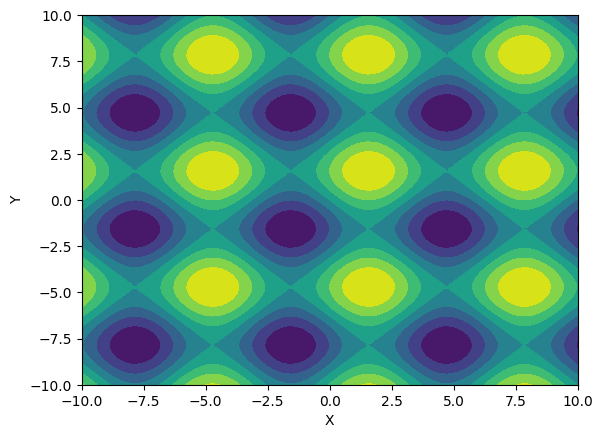

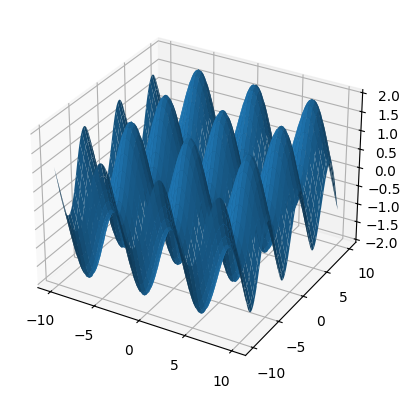

In [51]:
xwaarden = np.linspace(-10,10,100)
ywaarden = np.linspace(-10,10,100)
[X,Y] = np.meshgrid(xwaarden,ywaarden)
Z = np.sin(X) + np.sin(Y)

fig1,ax1=plt.subplots()
ax1.contourf(X,Y,Z)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")

fig2 = plt.figure()
ax2 = plt.axes(projection = "3d")
ax2.plot_surface(X,Y,Z) # type: ignore

### **1.28 Oefening 28**
Teken de parameterkromme bepaald door
$x = \cos(2t)$
$y = \sin(5t)$

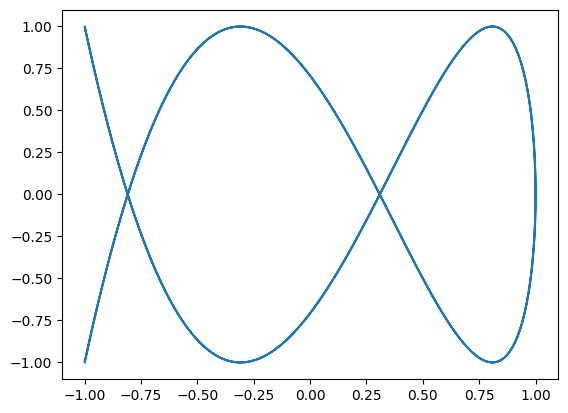

In [52]:
t=np.linspace(0,2*np.pi,500)
plt.plot(np.cos(2*t),np.sin(5*t))

### **1.29 Oefening 29**
Teken de parameterkromme bepaald door
$x = \cos(5t+\pi/4)$
$y = \sin(4t)$

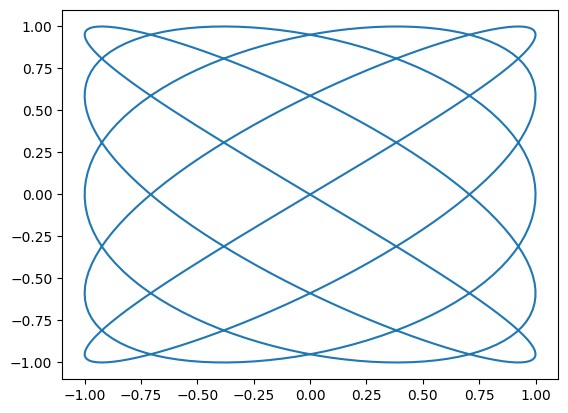

In [53]:
t=np.linspace(0,2*np.pi,500)
plt.plot(np.cos(5*t+np.pi/4),np.sin(4*t))

### **1.30 Oefening 30**
Teken een kromme in het complexe vlak waarbij $z=t~e^{i~t}$, $0\le t\le4\pi.$

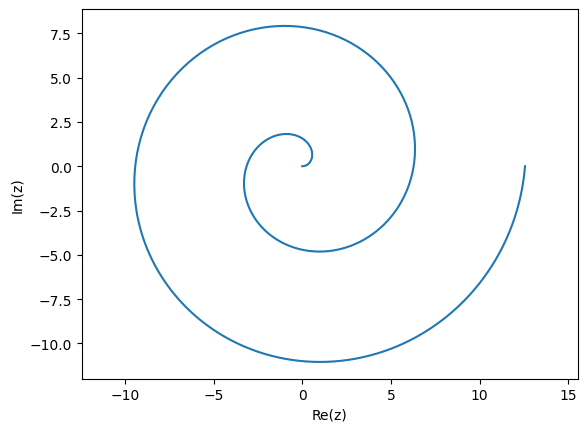

In [55]:
t=np.linspace(0,4*np.pi,500)
z=t*np.exp(1j*t)

plt.plot(z.real,z.imag)
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.axis("equal")
plt.show()

### **1.31 Oefening 31**
Schets de kromme met vergelijking $(y+1-x).(x^{2}+xy+y^{2}-x)=0.$ Bepaal de snijpunten van de verschillende onderdelen.
* **Oplossing:** $(1/3,-2/3)$ en (1, 0)

De snijpunten van de twee onderdelen zijn: [(1/3, -2/3), (1, 0)]


C:\Users\Talia\AppData\Local\Temp\ipykernel_10616\3293598447.py:19: UserWarning: The following kwargs were not used by contour: 'style'
  plt.contour(X, Y, Z1, levels=[0], colors='blue', style='dashed', linewidths=2)


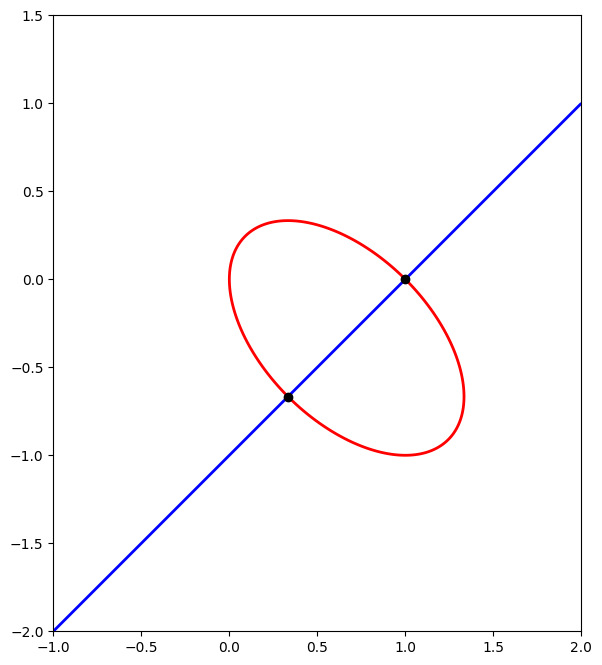

In [ ]:
x, y = sp.symbols('x y', real=True)

factor1 = y + 1 - x
factor2 = x**2 + x*y + y**2 - x

snijpunten = sp.solve([factor1, factor2], (x, y))

print(f"De snijpunten van de twee onderdelen zijn: {snijpunten}")

x_vals = np.linspace(-1, 2, 400)
y_vals = np.linspace(-2, 1.5, 400)
X, Y = np.meshgrid(x_vals, y_vals)

Z1 = Y + 1 - X
Z2 = X**2 + X*Y + Y**2 - X

plt.figure(figsize=(8, 8))

plt.contour(X, Y, Z1, levels=[0], colors='blue', linewidths=2)
plt.contour(X, Y, Z2, levels=[0], colors='red', linewidths=2)

for punt in snijpunten:
    plt.plot(float(punt[0]), float(punt[1]), 'ko', markersize=6, zorder=5)


plt.gca().set_aspect('equal')

plt.show()

### **1.32 Oefening 32**
Bepaal de oplossingen van het stelsel $\begin{cases}x^{2}+5y^{2}=25\\ x+y=2\end{cases}$


Schets de kromme en de rechte op één grafiek. Hoeveel snijpunten zijn er?
* **Oplossing:** twee snijpunten $(-0.234,2.234)=(\frac{5}{3}-\frac{\sqrt{130}}{6},\frac{1}{3}+\frac{\sqrt{130}}{6})$ en $(3.567,-1.567)=(\frac{5}{3}+\frac{\sqrt{130}}{6},\frac{1}{3}-\frac{\sqrt{130}}{6})$

Aantal snijpunten: 2

Snijpunt 1:
  Exact   : (5/3 - sqrt(130)/6, 1/3 + sqrt(130)/6)
  Numeriek: (-0.234, 2.234)

Snijpunt 2:
  Exact   : (5/3 + sqrt(130)/6, 1/3 - sqrt(130)/6)
  Numeriek: (3.567, -1.567)



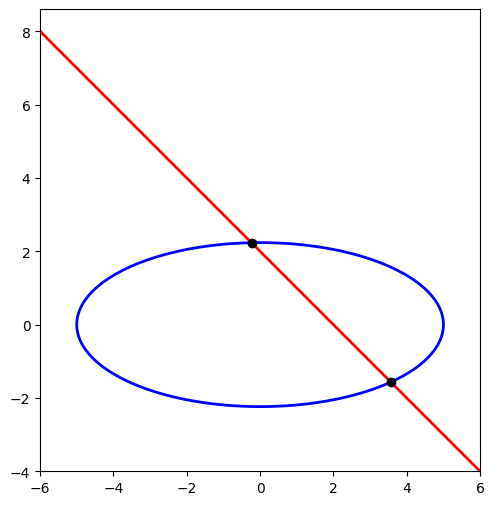

In [63]:
x, y = sp.symbols('x y', real=True)

eq1 = sp.Eq(x**2 + 5*y**2, 25)
eq2 = sp.Eq(x + y, 2)

snijpunten = sp.solve([eq1, eq2], (x, y))

print(f"Aantal snijpunten: {len(snijpunten)}\n")
for i, punt in enumerate(snijpunten):
    x_exact, y_exact = punt[0], punt[1]
    x_num, y_num = x_exact.evalf(), y_exact.evalf()
    print(f"Snijpunt {i+1}:")
    print(f"  Exact   : ({x_exact}, {y_exact})")
    print(f"  Numeriek: ({x_num:.3f}, {y_num:.3f})\n")

x_vals = np.linspace(-6, 6, 400)
y_vals = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x_vals, y_vals)

Z = X**2 + 5*Y**2 - 25

plt.figure(figsize=(8, 6))

plt.contour(X, Y, Z, levels=[0], colors='blue', linewidths=2)

plt.plot(x_vals, 2 - x_vals, color='red', linewidth=2)

for punt in snijpunten:
    plt.plot(float(punt[0]), float(punt[1]), 'ko', markersize=6, zorder=5)


plt.gca().set_aspect('equal')

plt.show()

### **1.33 Oefening 33**
Bepaal de reële oplossingen van $\begin{cases}x^{2}-2x+y^{2}=0\\ 9x^{2}-18x+4y^{2}=27\end{cases}$

Verklaar grafisch het resultaat.
* **Oplossing:** geen

oplossing: geen.


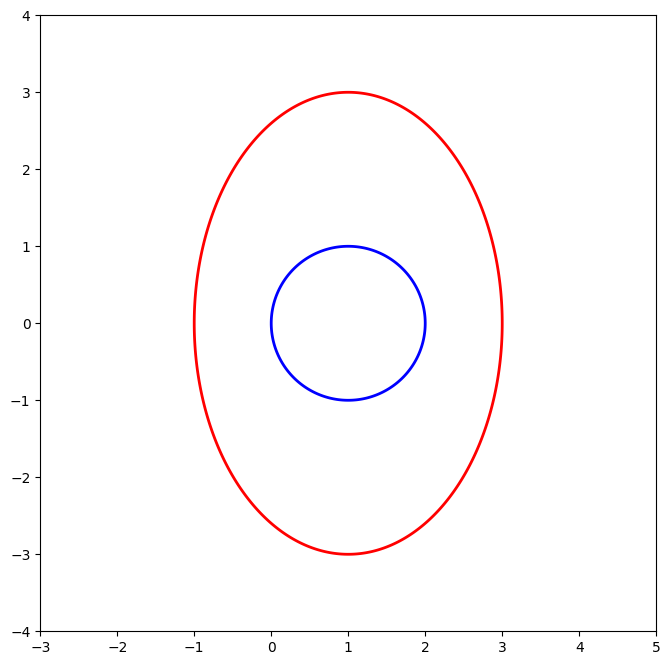

In [66]:
x, y = sp.symbols('x y', real=True)

eq1 = sp.Eq(x**2 - 2*x + y**2, 0)
eq2 = sp.Eq(9*x**2 - 18*x + 4*y**2, 27)

snijpunten = sp.solve([eq1, eq2], (x, y))

if len(snijpunten) == 0:
    print("oplossing: geen.")
else:
    print(f"De gevonden snijpunten zijn: {snijpunten}")

x_vals = np.linspace(-3, 5, 400)
y_vals = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x_vals, y_vals)

Z1 = X**2 - 2*X + Y**2
Z2 = 9*X**2 - 18*X + 4*Y**2 - 27

plt.figure(figsize=(8, 8))

plt.contour(X, Y, Z1, levels=[0], colors='blue', linewidths=2)
plt.contour(X, Y, Z2, levels=[0], colors='red', linewidths=2)

plt.gca().set_aspect('equal')

plt.show()

### **1.34 Oefening 34**
Teken de astroïde met vergelijking $\begin{cases}x=cos^{3}t\\ y=sin^{3}t\end{cases}$

Bepaal omtrek en oppervlakte.
*(omtrek $=\int_{t_{1}}^{t_{2}}\sqrt{(\frac{dx}{dt})^{2}+(\frac{dy}{dt})^{2}}dt;$ oppervlakte $=\int_{x_{1}}^{x_{2}}|y|dx)$*
* **Oplossing:** omtrek = 6, $opp=\frac{3\pi}{8}$

### **1.35 Oefening 35**
Teken de kromme $\begin{cases}x=2~sin(t)+cos(2~t)\\ y=-2~cos(t)-sin(2~t)\end{cases}.$

Bepaal via berekeningen voor welke waarden van de voerstraal van de punten maximaal zal zijn. Bepaal bovendien de cartesische coördinaten van deze punten.
* **Oplossing:** De drie t-waarden waarvoor de voerstraal maximaal is: $-\frac{\pi}{2},\frac{\pi}{6}$ en $\frac{5~\pi}{6}$. Dit leidt tot de punten $(\frac{3}{2},-\frac{3\sqrt{3}}{2})$ , $(\frac{3}{2},\frac{3\sqrt{3}}{2})$, (-3,0).

### **1.36 Oefening 36**
a) Teken de cardioide $r=1+cos~\theta$

b) Bereken de oppervlakte.

c) Bereken de omtrek.

* **TIP:** Oppervlakte in poolcoördinaten $S=\frac{1}{2}\int_{S_{t}}^{S_{2}}r^{2}d\mathcal{\theta}$, Booglengte in poolcoördinaten $s=\int_{\vec{Q}_{2}}\sqrt{r^{2}+{r^{\prime2}}^{2}}d\mathcal{\Theta}.$
* **Oplossing:** $opp=\frac{3\pi}{2}$, omtrek = 8

### **1.37 Oefening 37**
Teken een cirkel met middelpunt (1,2) en straal 2 via de parametervoorstelling en de expliciete voorstelling.

### **1.38 Oefening 38**
Onderzoek wat er gebeurt met de helling van de kromme $y=\frac{|x+2|}{(x+1)^{2}}$ rond $x=-2.$ Werk met limieten en controleer via een tekening.
* **Oplossing:** $LL=-1$, $RL=1$

### **1.39 Oefening 39**
a) Teken op één grafiek de krommen met vergelijking $r=1$ en $r=2~cos(3\theta)$.

b) Bereken de oppervlakte van het gemeenschappelijk deel binnen $r=1$ en $r=2~cos(3\theta)$.
* **Oplossing:** $\frac{2\pi}{3}-\frac{\sqrt{3}}{2}$

### **1.40 Oefening 40**
Teken de kromme met poolcoördinatenvergelijking $r=Bg~cos(\theta+1)$

### **1.41 Oefening 41**
Teken de lus van de poolkromme $r=\frac{1}{4~sin(\frac{\theta}{2})+cos(2\theta)}.$

### **1.42 Oefening 42**
Ga na in welke punten de cirkel met middelpunt (1,1) en straal 2 en de kromme $r=2-cos(2t)$ elkaar snijden in het vlak.
* **Oplossing:** (1.3619, -0.9670) en (0.4442, 2.9212)

### **1.43 Oefening 43**
Teken de poolkromme $r=sin(4t).$

### **1.44 Oefening 44**
Bereken de booglengte van de kromme $r=1-cos(t)$ gelegen buiten de kromme $r+\sqrt{3}sin(t)=0$
* **Oplossing:** 6

### **1.45 Oefening 45**
a) Teken $f(x)=e^{2~x+1}$ samen met zijn 2 afgekapte Taylorontwikkelingen rond x=1, resp. na de term in x en na de term in $x^{2}$.

b) Herhaal deze tekening voor $f(x)=x^{2}-x.$ Leg het resultaat uit.

### **1.46 Oefening 46**
Bepaal het inverse Laplacebeeld van $F(s)=\frac{2s^{3}+8s^{2}+12s+32}{s^{4}+4s^{3}+8s^{2}+16s+16}$
* **Oplossing:** $H(t)^{*}[2^{*}exp(-2^{*}t)+sin(2^{*}t)/2+3^{*}t^{*}exp(-2^{*}t)]$

### **1.47 Oefening 47**
Bepaal het Laplacebeeld van $\begin{cases}\sigma(t-1),&t<2\\ e^{t-2},t>2\end{cases}$
* **Oplossing:** $exp(-s)+exp(-2^{*}s)/(s-1)$

### **1.48 Oefening 48**
Bereken het Laplacebeeld van de functie die niet nul is tussen 1 en 2 en daar als functiewaarde 2-x aanneemt. Bereken van het resultaat het inverse Laplacebeeld en maak een tekening van de functie.
* **Oplossing:** $exp(-2^{*}s)/s^{\wedge}2+(exp(-s)^{*}(s-1))/s^{\wedge}2$

### **1.49 Oefening 49**
Bereken de Laplacegetransformeerde van g, waarbij je g definieert via de functie f (gedefinieerd over [0,1]) als $g(x)=f(x)+2^{*}f(x-1)+3^{*}f(x-2)$ en f samenvalt met de eerste bissectrice over [0,1] (anders functiewaarde 0).
* **Oplossing:** $g=1/s^{\wedge}2-(exp(-s)^{*}(s-1))/s^{\wedge}2-(3^{*}exp(-3^{*}s)^{*}(s+1))/s^{\wedge}2-(exp(-2^{*}s)^{*}(2^{*}s-1))/s^{\wedge}Z$

### **1.50 Oefening 50**
Bepaal eigenwaarden en eigenvectoren van de lineaire transformatie met transformatiematrix $A=\begin{pmatrix}2&0&1\\ 0&1&0\\ 1&0&2\end{pmatrix}.$

Controleer volgende eigenschappen:

(1) het spoor van de matrix is de som van de eigenwaarden (rekening houdend met multipliciteit)

(2) de determinant van de matrix is het product van de eigenwaarden (rekening houdend met multipliciteit)

### **1.51 Oefening 51**
Bepaal alle waarden van a zodat $|A|=-1$ met $A=\begin{pmatrix}1&a&0&6\\ 4&0&1&2\\ 1&3&-1&6\\ 1&10&3&11\end{pmatrix}.$
* **Oplossing:** 3.8230

### **1.52 Oefening 52**
Een oefening uit de cursus elektriciteit geeft aanleiding tot volgend stelsel:
$$\begin{cases}l_{2}-l_{1}-l_{2}=0\\ l_{2}-l_{1}-l_{2}-l_{2}=0\\ 30l_{4}+30l_{4}=-60\\ 30l+18l_{4}+30l=60\\ -30l_{4}+10l_{4}=200\end{cases}$$
Bepaal de stroomsterkten.
* **Oplossing:** $i_{1}=-4.2A$ $i_{2}=2.2~A,$ $i_{3}=6.4A,$ $i_{4}=9.8~A$ en $i_{5}=-3.4A$

### **1.53 Oefening 53**
Zoek een oplossing van het stelsel $\begin{cases}x+y-2z=3\\ 2x+3y+z=0.\\ y-z=1\end{cases}$
* **Oplossing:** $x=\frac{5}{6},$ $y=-\frac{1}{6}$ en $z=-\frac{7}{6}$

### **1.54 Oefening 54**
Bepaal een stel eigenvectoren van de lineaire transformatie $f:(x,y,z)\rightarrow(y+z,x+z,x+y)$.
* **Oplossing:** De eigenvectoren zijn: $k \begin{bmatrix}1\\ 1\\ 1\end{bmatrix}$ met $k\in IR$ en $k_{1}\begin{bmatrix}-1\\ 0\\ 1\end{bmatrix}+k_{2}\begin{bmatrix}-1\\ 1\\ 0\end{bmatrix}$ met $k_{1},k_{2}\in IR$

### **1.55 Oefening 55**
Bepaal een orthonormaal stel eigenvectoren van de lineaire transformatie $g:(x,y,z)\rightarrow(-x,-y,-z)$ Wat is de fysische interpretatie hiervan? Verklaar het resultaat.
* **Oplossing:** $IR^{3}$.

### **1.56 Oefening 56**
a) Bereken de eigenwaarden en eigenvectoren van $A=\begin{pmatrix}1&0&0\\ 1&1&0\\ 0&1&1\end{pmatrix}.$

b) Controleer de definitie van eigenwaarden en eigenvectoren.

c) Controleer dat de determinant van een matrix gelijk is aan het product van de eigenwaarden.

d) Controleer dat het spoor van een matrix gelijk is aan de som van de eigenwaarden.
* **Oplossing:** Er is één eigenwaarde $\lambda=1$ (met algebraïsche multipliciteit $=3$) Eigenvectoren: $k\begin{bmatrix}0\\ 0\\ 1\end{bmatrix}$ met k $\in$ IR

### **1.57 Oefening 57**
Zoek a zodat $f:(x,y,z)\rightarrow(oy+z,x+z,x+y)$ een eigenwaarde 1 heeft.
* **Oplossing:** $a=-1$

### **1.58 Oefening 58**
Bij een fabriek die klinkers maakt, wil men de maatvastheid onderzoeken van de geproduceerde klinkers. Daarvoor werd een steekproef gedaan en de lengte gemeten: 12, 13, 14, 16, 15, 18, 19, 10, 11, 12, 13, 14, 15, 13, 14, 12.

(a) Presenteer een histogram van deze gegevens.

(b) Vind de mediaan, de interkwartielafstand, de modus, het gemiddelde, variantie en het 10% percentiel.
* **Oplossing:** mediaan $=13.5000$, $iqr=3$, modus = 12, gemiddelde = 13.8125, variantie = 5.7625, 10% percentiel $=11.5$

### **1.59 Oefening 59**
Beschouw volgende meetwaarden voor x: 24, 19, 14, 10, 7, 5, 6, 8, 12, 16, 21, 27.

(a) Maak een boxplot.

(b) Ga na met 95% betrouwbaarheid of (op basis van deze gegevens) x een normale verdeling heeft.

(c) Ga na met 95% betrouwbaarheid of (op basis van deze gegevens) x een normale verdeling heeft met gemiddelde 7.
* **Oplossing:** De data zijn afkomstig van een normale verdeling (95% betrouwbaarheid). De data zijn niet afkomstig is van een normale verdeling met gemiddelde 7 (95% betrouwbaarheid).

### **1.60 Oefening 60**
Maak een simulatie met 100 steekproefwaarden van een variabele met een $F(7,5~df)$ -verdeling. Herhaal dit 400 keer. Maak passende tekeningen om hierin de centrale limietstelling te herkennen.

### **1.61 Oefening 61**
(a) Geef de boxplot voor volgende data: 25, 50, 22, 10, 28, 95, 20, 14, 25, 30. Bepaal de uitschieter(s).

(b) Test of de gegevens normaalverdeeld zijn op 80%-niveau.

(c) Verwijder de uitschieter en test opnieuw.
* **Oplossing:** * (b) Het normaal verdeeld zijn wordt niet aanvaard met 80% betrouwbaarheid.
  * De waarden 50 en 95 zijn blijkbaar uitschieters.
  * (c) Als we die weglaten, dan wordt het normaal verdeeld zijn aanvaard met 80% betrouwbaarheid.

### **1.62 Oefening 62**
In onderstaande tabel staan de maandelijkse nettolonen van een KMO in de bouwsector.

| Maandloon | Aantal werknemers |
| :--- | :--- |
| [1050, 1200[ | 4 |
| [1200, 1350[ | 7 |
| [1350, 1500[ | 10 |
| [1500, 1650[ | 12 |
| [1650, 1800[ | 7 |
| [1800, 1950[ | 3 |
| [1950, 2100[ | 0 |
| [2100, 2250[ | 2 |

(a) Schat het gemiddelde loon binnen deze KMO. Wat is de standaardafwijking?

(b) Bereken zelf het 95% betrouwbaarheidsinterval voor het gemiddelde loon voor een KMO in de bouwsector op basis van deze gegevens.
* **Oplossing:** Steekproefgemiddelde $=1525$, $s=247.7168,$ 95% Bl voor $\mu=[1450.6,1599.4]$

### **1.63 Oefening 63**
De resultaten (/100) behaald door een selectie van 10 studenten op het examen wiskunde en economie worden gegeven in onderstaande tabel.

| Student | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Score Wiskunde | 30 | 73 | 51 | 57 | 81 | 21 | 75 | 46 | 85 | 21 |
| Score Economie | 45 | 70 | 40 | 60 | 71 | 30 | 80 | 50 | 70 | 10 |

(a) Wat is de gemiddelde score voor het examen wiskunde bij deze 10 studenten?

(b) Schat de verwachte score voor het examen economie. Wat is daarbij de standaardfout?

(c) Bij welk examen is de variantie het grootst voor deze groep studenten?

(d) Maak een scatterplot waarbij je de score voor wiskunde uitzet ten opzichte van de score voor economie.
* **Oplossing:** (a) 54, (b) 52.6, standaardfout $=6.9109$, (c) variantie grootst bij wiskunde

### **1.64 Oefening 64**
Genereer een steekproef met 200 waarnemingen van een variabele met als verdeling $N(2,1).$ Teken de histogram van deze steekproef. Vind een interval waarin het steekproefgemiddelde van een dergelijke steekproef zal liggen met 80% betrouwbaarheid.

### **1.65 Oefening 65**
$Als~x:F(5,12~d.f.)$, dan is $P(x<2)=.....$
$Als~y:t(10~d.f.)$ dan is $P(y>I)=.....$
Wat is a als $P(y<a)=0.15$?
Als z: $Bin(n=500,$ $p=0.02)$, dan is $P(z<12)=.....$ (controleer dit laatste ook met de normale verdeling en geef commentaar)
* **Oplossing:** $P(x<2)=0.8491$, $P(y>1)=0.1704$, $P(y<-1.0931)=0.15$, $P(z<12)=0.6979$ (bin) benaderd als 0.6841.

### **1.66 Oefening 66**
Genereer zelf een steekproef met 100 waarnemingen van lengtes van planken. De leverancier stelt dat de lengtes normaal verdeeld zijn met gemiddelde 2 m en $\sigma=9$ cm. Onze zaagmachine zaagt van elke plank een deel af met een lengte die normaal verdeeld verondersteld wordt met gemiddelde 1.5 m en $\sigma=1$ cm. Simuleer dit. Welke verdeling verwacht je voor de lengtes van de overblijvende stukken van de planken als je weet dat de werking van de machine onafhankelijk is van de lengte van de plank. Controleer dit aan de hand van de grafieken van de cumulatieve distributiefuncties (theoretische functie in het rood met een puntlijn).

### **1.67 Oefening 67**
De afdeling kwaliteitscontrole van een fabriek die microgolfovens maakt, meet bij 42 ovens wat de straling is van de oven met gesloten deuren.

(a) Ga na of we er kunnen vanuit gaan dat deze emissie normaal verdeeld is.

(b) Ga na of er uitschieters zijn. Welke zijn die?

(c) Test of $\mu=0.10$ met $\alpha=0.05$.

(d) Geef een 99% betrouwbaarheidsinterval voor $\mu$.

Data: microgolf.CSV
* **Oplossing:**
  * De normale verdeling wordt verworpen met 95% betrouwbaarheid.
  * Boxplot: laat de uitschieter 0.4 zien.
  * De nulhypothese $\mu=0.10$ wordt dus aanvaard met 95% betrouwbaarheid.
  * Het 99% BI voor het gemiddelde $=\lceil0.0865, 0.1701]$.

### **1.68 Oefening 68**
Een consumentenorganisatie evalueert de kwaliteit van zonnepanelen. Daarvoor werden op 15 daken panelen geplaatst, één van type A en één van type B. De geleverde stroom (in kWh) werd opgemeten gedurende 3 maanden. Kan op basis van deze gegevens worden geconcludeerd dat er een significant verschil is in opgewekte stroom tussen de twee soorten panelen?

Data: zonnepaneel.CSV
* **Oplossing:** De normaliteit voor de verschilvariabele wordt aanvaard met 95% betrouwbaarheid. De gelijkheid van de geleverde stroom voor types A en B (in gepaarde vorm) wordt aanvaard met 95% betrouwbaarheid.

### **1.69 Oefening 69**
Een consumentenorganisatie evalueert de kwaliteit van zonnepanelen. Daarvoor wordt op 30 daken één type zonnepaneel gelegd: ofwel type A ofwel type B. De geleverde stroom (in kWh) werd opgemeten gedurende 3 maanden. Kan op basis van deze gegevens worden geconcludeerd dat er een significant verschil is $(\alpha=0.05)$ in opgewekte stroom tussen de twee soorten panelen op populatieniveau? Maak voor beide groepen een box-and-Whisker plot en becommentarieer.

Data: zonnepaneel.CSV
* **Oplossing:** De normaliteit wordt voor beide types panelen aanvaard met 95% betrouwbaarheid. Ook de voorwaarde van gelijkheid van varianties is voldaan (factor <2). De gelijkheid van de geleverde stroom voor types A en B wordt aanvaard met 95% betrouwbaarheid.

### **1.70 Oefening 70**
Van een partij wijn wordt verondersteld dat het gemiddeld alcoholgehalte gelijk is aan 12. Een steekproef van 10 flessen geeft volgend resultaat: 12.5, 13.8, 9.7, 12.9, 12.3, 10.7, 11.6, 12.3

(a) Is de bewering juist op populatieniveau $(\alpha=0.1)?$ (2-zijdige test) Kan je dit ook verklaren aan de hand van het betrouwbaarheidsinterval voor het gemiddelde?

(b) Test of het gemiddeld alcoholgehalte van de partij wijn kleiner is dan 12.5 op 80% niveau voor de ganse populatie. Kan je dit ook verklaren aan de hand van het betrouwbaarheidsinterval voor het gemiddelde?
* **Oplossing:** Er kan met 95% betrouwbaarheid worden aangenomen dat er een normale verdeling aanwezig is. Er kan met 90% betrouwbaarheid worden gezegd dat het gemiddeld alcoholgehalte gelijk is aan 12. Er kan met 80% betrouwbaarheid worden gezegd dat het gemiddeld alcoholgehalte kleiner is dan 12.5.

### **1.71 Oefening 71**
Voor het vervaardigen van synthetisch diamant wordt winst geboekt als de karaat-waarde > 0.5. Een steekproef van 6 diamanten geeft: 0.46, 0.61, 0.52, 0.48, 0.57, 0.54
Is algemeen gesproken de productie de moeite waard? (test op 85% niveau)
* **Oplossing:** De productie is de moeite waard met 85% betrouwbaarheid.

### **1.72 Oefening 72**
De hartslag vóór en na het toedienen van een bepaalde medicatie bij zeven personen geeft volgende resultaten:

| persoon: | 1 | 2 | 3 | 4 | 5 | 6 | 7 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| vóór | 55 | 59 | 60 | 58 | 61 | 62 | 65 |
| na | 57 | 62 | 62 | 62 | 60 | 64 | 64 |

Kan op basis van deze steekproef gesteld worden dat de hartslag op populatieniveau verhoogt door de medicatie $(\alpha=0.05)$?
* **Oplossing:** Met 95% betrouwbaarheid kan gesteld worden dat er een verhoging is van de hartslag.

### **1.73 Oefening 73**
De hartslag vóór en na het toedienen van een bepaalde medicatie bij zeven personen geeft volgende resultaten, waarbij 'hartslag sport' slaat op de resultaten van groep 1: personen die 2 uren sporten per week, en 'hartslag geen sport' slaat op de resultaten van groep 2: personen die geen sport doen.

| hartslag | 1 | 2 | 3 | 4 | 5 | 6 | 7 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Sport | 55 | 59 | 60 | 58 | 61 | 62 | 65 |
| Geen sport | 57 | 62 | 62 | 62 | 60 | 64 | 64 |

Kan op basis van deze steekproef gesteld worden dat de hartslag op populatieniveau hoger is voor de groep die geen sport doet $(\alpha=0.05)$?
* **Oplossing:** Met 95% betrouwbaarheid kan gesteld worden dat er geen verhoging is van de hartslag.

### **1.74 Oefening 74**
Machines produceren staafjes die een gemiddelde lengte van 12mm moeten hebben. Een steekproef van 10 staafjes bij 2 machines geeft volgende resultaten:

| Machine 1: | 11.9 | 12.3 | 11.8 | 12.1 | 12.7 | 11.7 | 11.4 | 11.5 | 11.9 | 12.0 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Machine 2: | 13.1 | 13.3 | 13.4 | 12.9 | 13.6 | 13.3 | 12.8 | 13.1 | 13.4 | 12.9 |

Steek deze data in één matrix om volgende vragen te beantwoorden.

(a) Bepaal voor beide steekproeven de gemiddelde lengte en het 90%-betrouwbaarheidsinterval.

(b) Test voor beide machines of de lengte inderdaad 12 is met 95%-betrouwbaarheid.

(c) Test of het gemiddelde voor machine 1 kleiner is dan 12 met 95%-betrouwbaarheid.

(d) Test of het gemiddelde voor machine 2 groter is dan 12 met 95%-betrouwbaarheid.

(e) Test of de gemiddelde lengte bij machine 2 meer dan 1 groter is dan bij machine 1 met 90%-betrouwbaarheid.
* **Oplossing:**
  * gemiddelde 11.9300 13.1800
  * normaliteit van lengte 1 wordt aanvaard met 95% betrouwbaarheid
  * normaliteit van lengte 2 wordt aanvaard met 95% betrouwbaarheid
  * 90% betrouwbaarheidsinterval voor lengte $1=[11.71,12.15]$
  * 90% betrouwbaarheidsinterval voor lengte $2=[13.03,13.33]$
  * gem_lengte1 $=12$ wordt aanvaard (tweezijdig met 95% betrouwbaarheid)
  * gem_lengte2 $=12$ wordt verworpen (tweezijdig met 95% betrouwbaarheid)
  * gem_lengte1<12 wordt verworpen (95% betrouwbaarheid)
  * gem_lengte2>12 wordt aanvaard (95% betrouwbaarheid)
  * gem_lengte2>gem_lengte1+1 wordt aanvaard (90% betrouwbaarheid)

### **1.75 Oefening 75**
Een onderzoek werd opgericht om na te gaan of de leeftijd van de autobestuurder invloed heeft op zijn rijgedrag, met name het aantal auto-ongevallen waarin hij betrokken geraakt gedurende een jaar. Test met een betrouwbaarheid van 95% of de leeftijd van de bestuurder los staat van het aantal ongevallen op populatieniveau?

Data: rijgedrag.CSV
* **Oplossing:** Met 95% betrouwbaarheid kan dus gesteld worden dat de leeftijd van de bestuurder een invloed heeft op het aantal ongevallen.

### **1.76 Oefening 76**
Tijdens een verkeerscontrole werden 1024 automobilisten gecontroleerd op het al dan niet dragen van de gordel. Daarvan waren er 464 mannen en 560 vrouwen. Van de mannen droegen er in totaal 192 een gordel. Van de 560 vrouwen waren dit er 284.

(a) Onderzoek of er een significante samenhang bestaat tussen het geslacht van de bestuurder en het dragen van de gordel.

(b) Indien er absolute onafhankelijkheid zou zijn tussen het rij- en kolomcriterium, hoeveel mannen zouden er een gordel dragen bij de 1024 automobilisten?
* **Oplossing:**
  * Met 95% betrouwbaarheid kan gesteld worden dat er een afhankelijkheid is tussen de gender van de bestuurder en het dragen van de gordel.
  * Indien er absolute onafhankelijkheid zou zijn tussen het rij- en kolomcriterium, zouden er 215.7 mannen een gordel dragen.

### **1.77 Oefening 77**
Men wenst te onderzoeken wie kiest voor het bouwen van passieve woningen. Daarvoor heeft men gepeild naar het opleidingsniveau van de mensen die een woning bouwen. Er wordt onderscheid gemaakt volgens drie klassen (groep $1=$ hoger opgeleiden, groep $2=$ middengroep, groep $3=$ laaggeschoolden). De aantallen staan genoteerd in volgende tabel.

| | groep 1 | groep 2 | groep 3 |
| :--- | :--- | :--- | :--- |
| Passieve woning | 14 | 30 | 11 |
| Geen passieve woning | 44 | 142 | 257 |

(a) Ga je op basis van deze steekproef akkoord met de stelling dat er geen verschil is qua opleidingsniveau bij de keuze voor een passieve woning op populatieniveau? $(\alpha=5\%)$?

(b) Hoeveel procent van de passieve woningen worden gebouwd door laaggeschoolden?

(c) Hoeveel procent van de hoger opgeleiden kiest voor een passieve woning?
* **Oplossing:**
  * Met 95% betrouwbaarheid kan gesteld worden dat er een afhankelijkheid is tussen het opleidingsniveau en het type woning.
  * 20% procent van de passieve woningen wordt gebouwd door laaggeschoolden.
  * 24.14% procent van de hoger opgeleiden kiest voor een passieve woning.

### **1.78 Oefening 78**
De dienst volksgezondheid wenst na te gaan of mensen die veel in de omgeving vertoeven van rokers, maar zelf niet-roker zijn, daar nadelige effecten van ondervinden. Om hier uitsluitsel over te geven werden drie groepen mensen geselecteerd: een groep rokers (groep 1), een groep niet-rokers die passief meeroken (groep 2) en een groep niet-rokers (groep 3) die ook niet in de buurt van rokers verblijven. De data die verzameld werden bestaan uit gemeten cotininewaarden (in $ng/ml$). Deze stof is aanwezig in het bloed en vormt zich wanneer nicotine wordt opgenomen door het bloed. Vergelijk de drie groepen. Controleer of kan aangenomen worden dat de varianties van de verschillende groepen overeenstemmen. Zijn de onderliggende verdelingen normaal verdeeld?
Voer de oefening op 2 manieren uit qua input van gegevens:

• Invoer in de vorm terug te vinden in onderstaande csv-file

• Invoer herschikt in een csv-file waarbij per kolom meetwaarden terug te vinden zijn van een welbepaalde groep

Data: cotinine.CSV
* **Oplossing:** Met 95% betrouwbaarheid kan gesteld worden dat er verschil is in cotininewaarden tussen de groepen $(p=9.0029e-05<0.05)$, meer bepaald tussen groep 1 en groep 2 en tussen groep 1 en groep 3. Het controleren van de normaliteit voor elk van de groepen levert telkens een positief resultaat op met 95% betrouwbaarheid.

### **1.79 Oefening 79**
Een onderzoeker is geïnteresseerd in de breeksterkte van verschillende gelamineerde balken gemaakt uit drie houtvariëteiten en drie verschillende soorten lijm. Om deze te vergelijken werden vijf balken van elk van de negen combinaties aangemaakt en daarna onderworpen aan een spanningstest. De data bestaat uit waarden voor de druk waarbij de balken braken. Maak een vergelijkend onderzoek waarbij je er mag van uitgaan dat de assumpties voor de testen voldaan zijn.

Data: balken.CSV
* **Oplossing:**
  * Er is interactie tussen de lijm en de houtsoort (95% betrouwbaarheid).
  * Het controleren van de normaliteit voor elk van de groepen levert telkens een positief resultaat op met 95% betrouwbaarheid.

### **1.80 Oefening 80**
Men wenst onderzoek te doen rond verschillende samenstellingen om het wegdek van de snelweg mee te bouwen. Bij een proefproject worden de vier verschillende types wegdek (die verschillen qua samenstelling van de asfalt) gebruikt op de E17, de E40, de R4 en de E413, telkens met een strook van 1 km. Na vijf jaar wordt geëvalueerd hoeveel herstellingen dienden te gebeuren (zie tabel). Maak een totale variantie-analyse voor wat betreft de types wegdek op de verschillende snelwegen waarbij je er mag van uitgaan dat de assumpties voor de testen voldaan zijn.

| | Type I | Type II | Type III | Type IV |
| :--- | :--- | :--- | :--- | :--- |
| E17 | 4 | 3 | 6 | 10 |
| E40 | 10 | 8 | 5 | 16 |
| R4 | 2 | 0 | 3 | 4 |
| E413 | 1 | 2 | 3 | 4 |

* **Oplossing:**
  * Zowel de rij (snelweg) als de kolom (soort asfalt) hebben een significante invloed $(\alpha=0.05)$.
  * Tussen E40 en E413 is er een significant verschil, evenals tussen E40 en R4 $(\alpha=0.05)$.
  * Tussen asfalt type 2 en asfalt type 4 is er ook een significant verschil (met 95% betrouwbaarheid).

### **1.81 Oefening 81**
Op verschillende plaatsen worden watermonsters genomen en het zuurstofgehalte bepaald:
plaats 1: stroomopwaarts
plaats 2: nabij een fabriek
plaats 3: stroomafwaarts
Ga na of er een significant verschil is tussen de plaatsen.

| Plaats | | Gemiddelde zuurstof | | |
| :--- | :--- | :--- | :--- | :--- |
| 1 | 6.3 | 6.6 | 6.4 | 6.5 |
| 2 | 4.8 | 4.3 | 5.0 | 5.1 |
| 3 | 6.0 | 6.2 | 6.3 | 6.2 |

* **Oplossing:**
  * Voorwaarden (normaliteit en gelijkheid van varianties) om de test uit te voeren zijn voldaan.
  * Met 95% betrouwbaarheid kan een verschil gevonden worden in zuurstofgehalte volgens de locatie. (significant verschil tussen locatie 2 en 1 en tussen locatie 2 en 3)

### **1.82 Oefening 82**
Er wordt een studie gedaan waarin de Fe-concentratie bepaald wordt in grondstalen. Op 3 verschillende plaatsen worden telkens zes stalen genomen en de metingen op elk staal worden uitgevoerd in 2 verschillende labo's, die elk een andere meettechniek gebruiken. In de onderstaande tabel worden de resultaten weergegeven. Ga na in hoeverre het labo (factor A) en de plaats (factor B) effect hebben op de meting ( $(\alpha=0.05).$

| | plaats 1 | 2 | 3 |
| :--- | :--- | :--- | :--- |
| Labo 1 | 5.59 | 5.67 | 5.75 |
| | 5.59 | 5.67 | 5.47 |
| | 5.37 | 5.55 | 5.43 |
| | 5.54 | 5.57 | 5.45 |
| | 5.37 | 5.43 | 5.24 |
| | 5.42 | 5.57 | 5.47 |
| Labo 2 | 5.90 | 5.90 | 5.81 |
| | 5.75 | 6.01 | 5.90 |
| | 6.07 | 5.85 | 5.81 |
| | 5.90 | 5.54 | 5.81 |
| | 6.01 | 5.81 | 5.65 |
| | 6.06 | 5.70 | 5.75 |

* **Oplossing:**
  * Voorwaarden (normaliteit en gelijkheid van varianties) om de test uit te voeren zijn voldaan.
  * Met 95% betrouwbaarheid doet de plaats er niet toe voor de Fe-concentratie, maar wel het labo.

### **1.83 Oefening 83**
Men veronderstelt dat de concentratie van een katalysator invloed heeft op de sterkte bij kunststof. Metingen van de sterkte geven volgend resultaat:

| Concentratie 35% | 40% | 45% | 50% |
| :--- | :--- | :--- | :--- |
| 5.9 | 9.9 | 6.8 | 7.2 |
| 8.1 | 9.0 | 7.9 | 6.9 |
| 5.6 | 8.6 | 8.4 | 7.7 |
| 6.3 | 7.9 | 9.3 | 8.1 |
| 7.7 | 8.7 | 8.2 | 7.5 |

Ga na of de bewering klopt op populatieniveau $(\alpha=0.05)$.
* **Oplossing:**
  * Voorwaarden (normaliteit en gelijkheid van varianties) om de test uit te voeren zijn voldaan.
  * Met 95% betrouwbaarheid kan er een verschil gevonden worden bij de sterkte van de kunststof volgens de concentratie. Meer bepaald tussen 35% en 40%.

### **1.84 Oefening 84**
Beschouw volgende gegevens:

| | Pol | Piet | Lena | Lies | Dirk | Sara | Miel | Kurt | Linda | Sven |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Test 1 | 8 | 12 | 13 | 10 | 16 | 9 | 3 | 19 | 14 | 9 |
| Test 2 | 5 | 13 | 12 | 14 | 17 | 10 | 1 | 14 | 12 | 7 |

(a) Bepaal het 90% betrouwbaarheidsinterval voor het populatiegemiddelde van het rekenkundig gemiddelde van de twee testen.

(b) Bepaal de correlatiecoëfficiënt tussen de twee testen en test of deze significant verschillend is van 0.
* **Oplossing:**
  * (a) [8.2904, 13.5096]
  * (b) 0.8509, significant verschillend is van 0 $(\alpha=0.05)$

### **1.85 Oefening 85**
Het maximale debiet y van een rivier is een belangrijke parameter voor vele ontwerpproblemen voor civiele ingenieurs. Schattingen van deze parameter kunnen bekomen worden door deze te verbinden met de oppervlakte van de waterscheiding (x1) (grens tussen twee stroomgebieden) en de gemiddelde waterscheidingshelling (x2).

(a) Schat het verband door middel van meervoudige lineaire regressie.

(b) Test of elk van de coëfficiënten significant verschillend zijn van 0.

(c) Hoeveel procent van de variantie kan verklaard worden door het regressiemodel? Interpreteer.

(d) Wat is de correlatiecoëfficiënt tussen de veranderlijken $x_{1}$ en $x_{2}$ ?

Data: debiet.CSV
* **Oplossing:**
  * (a-c) Een lineair model is niet aangewezen om het debiet te verklaren met $X_{1}$ en X2.
  * (d) -0.4741 = correlatiecoëfficiënt tussen de veranderlijken $X_{1}$ en x2

### **1.86 Oefening 86**
Bij een audit van de helpdesk-afdeling van een softwarebedrijf wordt 13 dagen lang het aantal binnenkomende tickets genoteerd. Men noteert ook elke dag het aantal beschikbare medewerkers en het aantal binnenkomende tickets dat die dag voor langere tijd in de wachtrij belandt (meer dan 1 uur wachttijd).
(a) Teken een boxplot van de variabele X die aanduidt hoeveel tickets minder dan 1 uur in de wachtrij staan na aankomst.

(b) In 75% van de gevallen is X kleiner dan ...

(c) Zijn er uitschieters voor X?

(d) Stel het best passende lineair regressiemodel op om X te voorspellen a.d.h.v. het aantal medewerkers $(=M)$.

(e) Hoe zijn X en M gecorreleerd? Bereken de gepaste coëfficiënt en ga na of deze significant verschillend is van nul.

| Aantal inkomende tickets | Aantal medewerkers | Langer dan 1 uur in wachtrij |
| :--- | :--- | :--- |
| 83 | 6 | 12 |
| 50 | 5 | 3 |
| 91 | 7 | 7 |
| 45 | 5 | 8 |
| 66 | 6 | 17 |
| 72 | 7 | 4 |
| 73 | 6 | 8 |
| 80 | 9 | 2 |
| 52 | 5 | 3 |
| 90 | 7 | 17 |
| 89 | 9 | 19 |
| 46 | 5 | 5 |
| 58 | 7 | 7 |

* **Oplossing:**
  * In 75% van de gevallen is X kleiner dan 71.
  * De correlatiecoefficient $=0.7291$ en die is significant verschillend van 0.
  * X=7.9470 M + 8.8808 is een significant lineair regressiemodel, maar kan verbeterd worden tot het model $X=9.2650~M$
  * Geen uitschieters voor X volgend uit de boxplot.

### **1.87 Oefening 87**
Een bedrijf wil het effect nagaan van hun advertenties op de verkoop. In een periode van 6 maanden vinden we de volgende cijfers voor omzet en uitgaven aan reclame.

| maand | Uitgaven reclame | omzet |
| :--- | :--- | :--- |
| Januari | 1200 | 16 000 |
| Februari | 1400 | 18 000 |
| Maart | 2700 | 34 000 |
| April | 3800 | 55 000 |
| Mei | 4000 | 52 000 |
| Juni | 4200 | 58 000 |
| Juli | 3400 | 45 000 |
| Augustus | 2800 | 37 000 |

a) Kunnen we stellen dat de grootte van het reclamebudget toelaat om het verkoopresultaat te voorspellen? Zo ja, hoe dan? Stel het model op op basis van deze gegevens. Bespreek.

b) Wat verwacht je als omzet indien het bedrijf 20 000 euro uitgeeft aan reclame?

c) Maak een grafische voorstelling waarbij je op één tekening de reclame-uitgaven en ook de omzet uitzet als functie van de tijd met een lijn (met een legende).

d) Maak een staafdiagram waarbij je op één tekening de reclame-uitgaven en ook de omzet uitzet als functie van de tijd (met een legende).
* **Oplossing:**
  * (a) Het best passende lineaire model is omzet $=13.4758*$ reclame
  * (b) 269 516 als omzet

### **1.88 Oefening 88**
Gasmaatschappijen moeten voldoende gastoevoer voorzien om hun klanten het ganse jaar door te bevoorraden. Bij de planning wil men in staat zijn de benodigde hoeveelheid te voorspellen op basis van gegevens rond temperatuur van de dag zelf, van de voorbije dag, de windsnelheid, het feit of het weekend is of niet.

(a)Stel op basis van de data die voorhanden is, een lineair regressiemodel op dat ons in staat moet stellen om de nodige gashoeveelheid te modelleren.

(b) Hoeveel procent van de variantie kan verklaard worden door het regressiemodel? Interpreteer.

(c) Wat is volgens het model de hoeveelheid gas die de maatschappij moet voorzien als de temperatuur van de dag (woensdag) gelijk is aan18 graden Celcius, de temperatuur van de dag ervoor 15 graden Celcius, de windsnelheid 10 bedraagt?

(d) Wat is volgens het model het 95% betrouwbaarheidsinterval voor de coëfficiënt bij de temperatuur van de dag?

Data: gasbedrijf.CSV
* **Oplossing:**
  * (a) gastoevoer $=399.4760-6.7086^{*}$ temperatuur
  * (b) $R^{2}=97.4\%$
  * (c) 278.72
  * (d) [-7.6026, -5.8147]

### **1.89 Oefening 89**
Opgave:
Twee wijnproevers werd gevraagd een rangschikking te maken van 9 gegeven wijnen.

(a) Bereken de correlatiecoëfficiënt van de scores van beide wijnproevers en trek er je conclusies uit over de mening van de twee kenners.

(b) Maak een gepaste grafiek die het verband tussen de 2 beoordelingen weergeeft.

Data: wijndegustatie.CSV
* **Oplossing:** De gemeten correlatiecoëfficiënt is 0.1333. We kunnen met 95% betrouwbaarheid stellen dat de correlatiecoëfficiënt op populatieniveau gelijk is aan 0.

### **1.90 Oefening 90**
Het gewicht van personen wordt vergeleken met de systolische bloeddruk. Dit geeft:

| Gewicht: | 81 | 92 | 83 | 75 | 81 | 77 | 92 | 101 | 87 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Bloeddruk: | 122 | 144 | 138 | 145 | 152 | 110 | 118 | 160 | 108 |

Bepaal het lineair verband dat algemeen de bloeddruk uitdrukt in termen van het gewicht. Bespreek voor $\alpha=0.05$.
* **Oplossing:** Er is geen waardevol lineair model te vinden. $R^{\wedge}2=8.8\%$

### **1.91 Oefening 91**
Gegeven zijn volgende meetresultaten:

| X: | 1.5 | 2 | 3.1 | 4.2 | 5 | 6.1 | 6.9 | 8.3 | 9.5 | 10.1 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| y: | 7 | 20 | 65 | 64 | 187 | 430 | 600 | 1300 | 2000 | 3500 |

Bepaal op basis van deze gegevens het best passende lineair verband $y=\beta_{0}+\beta_{1}x$ Kan je het model verbeteren?
* **Oplossing:** betere modellen: $y=70.43^{*}x^{\wedge}2-490.8^{*}x+751.4$ en $y=6.0642~e^{0.6645x}$

### **1.92 Oefening 92**
Men onderzoekt de expansie van een grote winkelketen. Hieronder vind je een overzicht van het aantal geopende winkels (y) in de loop van 12 jaar. Vind het best passende veeltermmodel dat het aantal winkels verklaart in functie van de jaren. Argumenteer.

| t in jaar | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| aantal winkels | 1 | 2 | 2 | 6 | 10 | 16 | 25 | 41 | 60 | 97 | 150 | 211 |

* **Oplossing:** y = 2.878 *x^2-21.05 *x + 32.7

### **1.93 Oefening 93**
Men wil bestuderen hoe de weerstand van rubber tegen afschuren beïnvloed wordt door de hardheid en treksterkte van rubber. Twintig monsters rubber zijn getest op de hardheid (hoe hoger het getal des te sterker is het rubber) en treksterkte (in $kg/cm^{2})$. Daarna is elk monster een uurlang afgeschuurd (elk monster op dezelfde manier) en is het afgeschuurde gewicht (in gram) aan rubber per uur (y) bepaald. Bepaal het meervoudige lineaire model $y=\beta_{0}+\beta_{1}x_{1}+\beta_{2}x_{2}$ en illustreer met een 3D tekening.

| hardheid | treksterkte | Y | hardheid | treksterkte |
| :--- | :--- | :--- | :--- | :--- |
| 372 | 45 | 162 | 164 | 64 | 210 |
| 206 | 55 | 233 | 113 | 68 | 210 |
| 175 | 61 | 232 | 82 | 79 | 196 |
| 154 | 66 | 231 | 32 | 81 | 180 |
| 136 | 71 | 131 | 228 | 56 | 200 |
| 112 | 71 | 237 | 196 | 68 | 173 |
| 55 | 81 | 224 | 128 | 75 | 188 |
| 45 | 86 | 219 | 97 | 83 | 161 |
| 221 | 53 | 203 | 64 | 88 | 119 |
| 166 | 60 | 189 | 249 | 59 | 161 |

* **Oplossing:**
  * model: y=721.7233-6.6207 x1 -0.6139 x2
  * (normaliteitsvoorwaarde voor residues voldaan)

### **1.94 Oefening 94**
Er wordt nagegaan of de lengte van een pasgeboren baby afhankelijk is van de gewichtstoename van de moeder tijdens de zwangerschap en/of van de lengte van de vader. 10 steekproeven geven volgende resultaten:

| gew toename: | 12 | 13 | 15 | 20 | 14 | 13 | 10 | 19 | 12 | 8 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| lengte vader: | 195 | 180 | 175 | 182 | 165 | 190 | 182 | 177 | 171 | 179 |
| lengte baby: | 52 | 52.5 | 50 | 51 | 50 | 53 | 52.5 | 52 | 49 | 50.5 |

Kan je een meervoudig lineair model bepalen dat de lengte van de baby voorspelt als de gewichtstoename van de moeder en de lengte van de vader gekend zijn. Verklaar.
* **Oplossing:** lengte baby $=31.3508+0.1108^{*}$ lengte vader